## Simulating two vessels passing a lock: two opposing directed vessels with empty lock operation
In this notebook, we simulate a lock complex on a network. We model two opposing directed vessels that have to pass the complex, one waiting for the other to be levelled. Given the FCFS (First-Come-First-Serve) policy of the Lock Master, an empty lock operation has to be scheduled, as the side to which the door is initially opened is different from the side where the first vessel arrives.

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# import of basic core mixins and utils for creating objects, inspecting the output and plotting
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.utils import create_object
from opentnsim.core.visualizations import generate_vessel_gantt_chart

# import of util for graph visualization
from opentnsim.graph.visualizations import plot_graph

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable

# package(s) needed for inspecting the output
import pandas as pd

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.3.2a2.dev3+g514a752b4.d20260603


#### 0. Create environment

In [2]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

#### 1. Create graph
We create the same graph layout as in notebooks 0201 and 0202

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.DiGraph()

# add nodes
graph.add_node('0',geometry=transform(wgs84eqd_to_wgs84rad, Point(-5000,0)))
graph.add_node('1',geometry=transform(wgs84eqd_to_wgs84rad, Point(5000,0)))

# add edges
graph.add_edge('0','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(5000, 0)])), weight=1, length_m=10000)
graph.add_edge('1','0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(-5000, 0)])), weight=1, length_m=10000)

# add graph to environment
env.graph = graph

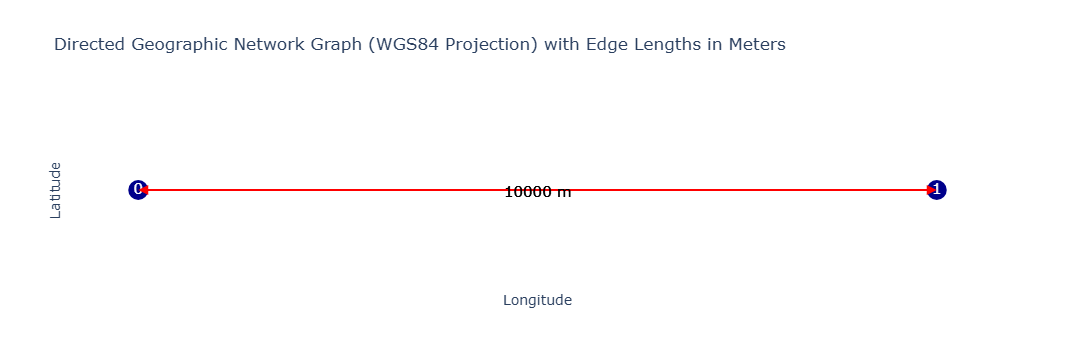

In [4]:
plot_graph(graph)

#### 1+ Adding infrastructure
As an addition to the previous notebooks, we can add a parameter <i>gate_open_at_node</i> to indicate at which node the gate is initially open.

In [5]:
lock_chamber = IsLockChamber(env=env,
                             lock_depth = 10,
                             name='Lock',
                             gate_open_at_node = '1',
                             edge = ('0','1'),
                             geometry_m = Polygon([Point(-200, -25),Point(-200, 25),Point(200, 25),Point(200, -25)]))

In [6]:
waiting_area_A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area A',
                                   edge = ('0','1'),
                                   orientation = 0,
                                   distance_from_edge_start = 0)

waiting_area_B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area B',
                                   edge = ('1','0'),
                                   orientation = 1,
                                   distance_from_edge_start = 0)

In [7]:
lock_complex = IsLockComplex(lock_chambers = [lock_chamber],
                             waiting_areas = [waiting_area_A, waiting_area_B],
                             registration_nodes = ['0','1'],
                             env=env,
                             name = 'Lock complex',)

#### 2. Create agents
We create the same agents as in notebook 0201

In [8]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (
        LockComplexTraversable,     # allows to interact with a lock
    ), 
)

In [9]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [10]:
# create vessels from dict 
data_vessel_1 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 1",                                  # required by Identifiable
    "geometry": env.graph.nodes['0']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "0", "1"),      # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 5,                                              # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:00:00')  # required by PassesLockComplex
}  
vessel_1 = Vessel(**data_vessel_1)
vessel_1.name = 'Vessel 1'

data_vessel_2 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 2",                                  # required by Identifiable
    "geometry": env.graph.nodes['1']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "1", "0"),      # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 5,                                              # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:05:00')  # required by PassesLockComplex
}  
vessel_2 = Vessel(**data_vessel_2)
vessel_2.name = 'Vessel 2'

# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2));

#### 3. Run simulation

In [11]:
env.run()

,node_from,node_to,direction,lock_chamber,operation_index,vessels,capacity_L,capacity_B,time_potential_lock_gate_opening_stop,time_lock_operation_start,...,time_gate_opening_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
0,0,1,0,Lock,1,[<opentnsim.core.utils.Vessel object at 0x0000...,300.0,50.0,2025-01-01 00:17:00,2025-01-01 00:18:27.500000,...,2025-01-01 00:45:40.172786470,2025-01-01 00:45:40.172786470,2025-01-01 00:46:28.768898822,2025-01-01 00:48:01.268898822,2025-01-01 00:48:28.768898822,NaN,NaN,NaN,NaN,NaN


hiii Vessel 1


,node_from,node_to,direction,lock_chamber,operation_index,vessels,capacity_L,capacity_B,time_potential_lock_gate_opening_stop,time_lock_operation_start,...,time_gate_opening_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
1,1,0,1,Lock,0,[],400.0,50.0,2025-01-01 00:00:00,2025-01-01 00:00:00,...,2025-01-01 00:20:00,2025-01-01 00:20:00,2025-01-01 00:20:00,2025-01-01 00:20:00,2025-01-01 00:20:00,NaN,NaN,NaN,NaN,NaN
0,0,1,0,Lock,1,[<opentnsim.core.utils.Vessel object at 0x0000...,300.0,50.0,2025-01-01 00:18:32.500000,2025-01-01 00:20:00,...,2025-01-01 00:47:12.672786470,2025-01-01 00:47:12.672786470,2025-01-01 00:48:01.268898822,2025-01-01 00:49:33.768898822,2025-01-01 00:50:01.268898822,NaN,NaN,NaT,NaT,NaN
2,1,0,1,Lock,2,[<opentnsim.core.utils.Vessel object at 0x0000...,300.0,50.0,2025-01-01 00:49:33.768898822,2025-01-01 00:49:33.768898822,...,2025-01-01 01:16:46.441685292,2025-01-01 01:16:46.441685292,2025-01-01 01:17:35.037797644,2025-01-01 01:19:07.537797644,2025-01-01 01:19:35.037797644,NaN,NaN,NaN,NaN,NaN


hiii Vessel 2


#### 4. Inspect output
##### Vessel logbooks
Based on the vessel logbooks, both vessels now experience waiting time. The first vessel experiences a waiting time as the empty levelling operation takes time. The second vessel now experiences more waiting time to wait for both the empty lock operation and the lock operation for the first vessel.

In [12]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2025-01-01 00:00:00.000000,0.0,POINT (-0.0449157642059761 0)
1,Waiting for lock operation start,2025-01-01 00:00:00.000000,0.0,POINT (-0.0449157642059761 0)
2,Waiting for lock operation stop,2025-01-01 00:01:32.500000,0.0,POINT (-0.0449157642059761 0)
3,Sailing to first lock gate start,2025-01-01 00:01:32.500000,0.0,POINT (-0.0449157642059761 0)
4,Sailing to first lock gate stop,2025-01-01 00:21:32.500000,4800.0,POINT (-0.001796630568239 0)
5,Sailing to position in lock start,2025-01-01 00:21:32.500000,4800.0,POINT (-0.001796630568239 0)
6,Sailing to position in lock stop,2025-01-01 00:27:12.672786,5150.0,POINT (0.0013474729261793 0)
7,Waiting for lock gate closing start,2025-01-01 00:27:12.672786,5150.0,POINT (0.0013474729261793 0)
8,Waiting for lock gate closing stop,2025-01-01 00:32:12.672786,5150.0,POINT (0.0013474729261793 0)
9,Waiting for lock levelling start,2025-01-01 00:32:12.672786,5150.0,POINT (0.0013474729261793 0)


In [13]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_2.logbook)

print("'{}' logbook data:".format(vessel_2.name))  
print('')

display(df)

'Vessel 2' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 1 to node 0 start,2025-01-01 00:05:00.000000,0.0,POINT (0.0449157642059761 0)
1,Waiting for lock operation start,2025-01-01 00:05:00.000000,0.0,POINT (0.0449157642059761 0)
2,Waiting for lock operation stop,2025-01-01 00:31:06.268898,0.0,POINT (0.0449157642059761 0)
3,Sailing to first lock gate start,2025-01-01 00:31:06.268898,0.0,POINT (0.0449157642059761 0)
4,Sailing to first lock gate stop,2025-01-01 00:51:06.268898,4800.0,POINT (0.001796630568239 0)
5,Sailing to position in lock start,2025-01-01 00:51:06.268898,4800.0,POINT (0.001796630568239 0)
6,Sailing to position in lock stop,2025-01-01 00:56:46.441684,5150.0,POINT (-0.0013474729261793 0)
7,Waiting for lock gate closing start,2025-01-01 00:56:46.441685,5150.0,POINT (-0.0013474729261793 0)
8,Waiting for lock gate closing stop,2025-01-01 01:01:46.441685,5150.0,POINT (-0.0013474729261793 0)
9,Waiting for lock levelling start,2025-01-01 01:01:46.441685,5150.0,POINT (-0.0013474729261793 0)


##### Lock chamber logbook
The logbook of the lock chamber indeed shows that three lock operations were required

In [14]:
# load the logbook data into a dataframe
lock_df = pd.DataFrame.from_dict(lock_chamber.logbook)

print("'{}' logbook data:".format(lock_chamber.name))  
print('')

display(lock_df)

'Lock' logbook data:



,Message,Timestamp,Value,Geometry
0,Lock gate closing start,2025-01-01 00:27:12.672786,1,POLYGON ((-0.001796630568239 -0.00022457882102...
1,Lock gate closing stop,2025-01-01 00:32:12.672786,1,POLYGON ((-0.001796630568239 -0.00022457882102...
2,Lock levelling start,2025-01-01 00:32:12.672786,1,POLYGON ((-0.001796630568239 -0.00022457882102...
3,Lock levelling stop,2025-01-01 00:42:12.672786,0,POLYGON ((-0.001796630568239 -0.00022457882102...
4,Lock gate opening start,2025-01-01 00:42:12.672786,0,POLYGON ((-0.001796630568239 -0.00022457882102...
5,Lock gate opening stop,2025-01-01 00:47:12.672786,0,POLYGON ((-0.001796630568239 -0.00022457882102...
6,Lock gate closing start,2025-01-01 00:56:46.441685,0,POLYGON ((-0.001796630568239 -0.00022457882102...
7,Lock gate closing stop,2025-01-01 01:01:46.441685,0,POLYGON ((-0.001796630568239 -0.00022457882102...
8,Lock levelling start,2025-01-01 01:01:46.441685,0,POLYGON ((-0.001796630568239 -0.00022457882102...
9,Lock levelling stop,2025-01-01 01:11:46.441685,1,POLYGON ((-0.001796630568239 -0.00022457882102...


##### Time-distance diagram
The time-distance diagram indeed confirms double waiting times, and three lock operations.

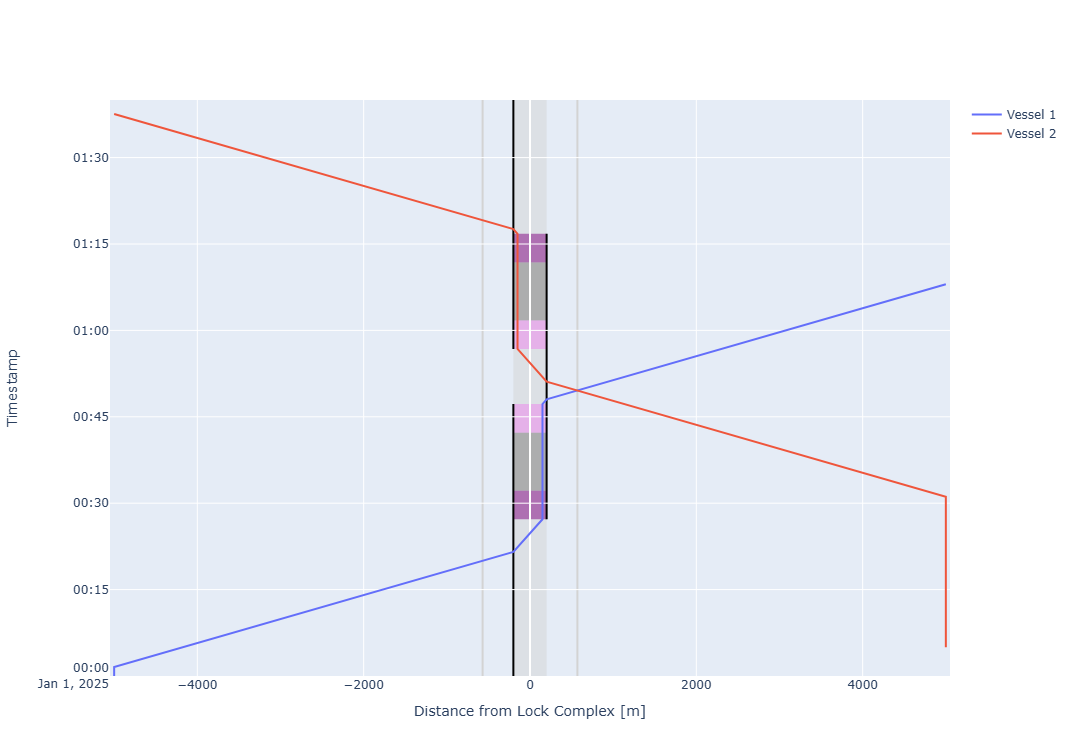

In [15]:
def cm_to_pixels(cm):
    return cm * 37.8 # Set figure height to 10 cmfig.update_layout(height=cm_to_pixels(10))

# We can plot the time-distance diagram
fig = lock_chamber.plot(xlimmin = -5050, 
                        xlimmax = 5050, 
                        ylimmin = pd.Timestamp('2025-01-01 00:00:00'),
                        ylimmax = pd.Timestamp('2025-01-01 01:40:00'),
                        method='Plotly')

fig.update_layout(height=cm_to_pixels(20))

##### Event chart
As does the event chart

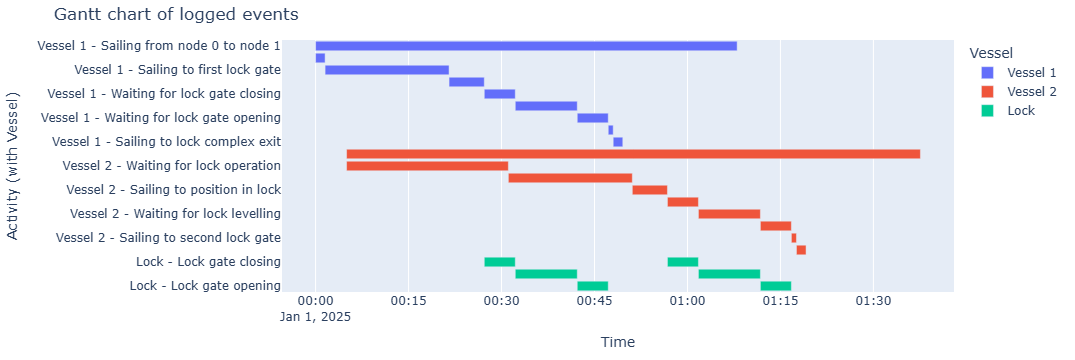

In [16]:
df_eventtable = logbook2eventtable([vessel_1, vessel_2, lock_chamber])
generate_vessel_gantt_chart(df_eventtable)